## Otros Algoritmos de Reducción de Dimensionalidad

**LDA (Análisis Discriminante Lineal)**

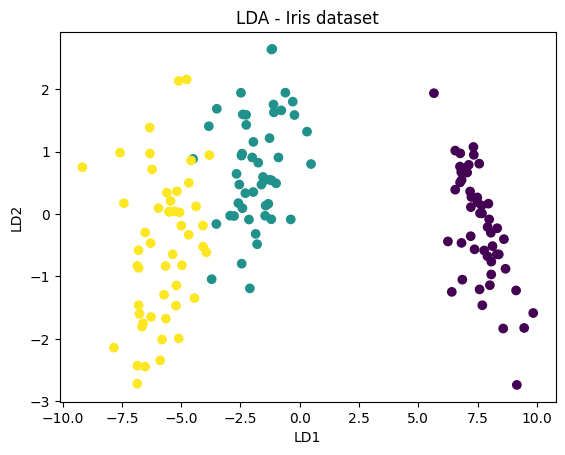

In [11]:
from sklearn.datasets import load_iris

data = load_iris()
X = data.data
y = data.target

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X, y)

import matplotlib.pyplot as plt

plt.scatter(X_lda[:,0], X_lda[:,1], c=y, cmap="viridis")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA - Iris dataset")
plt.show()

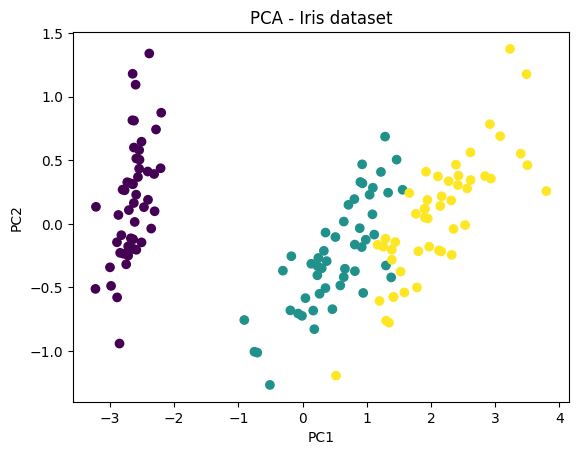

In [12]:
# PCA no usa las clases, solo mira la estructura de los datos.

from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

data = load_iris()

X = data.data
y = data.target

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap="viridis")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - Iris dataset")

plt.show()


| Método | Usa clases | Objetivo           |
| ------ | ---------- | ------------------ |
| PCA    | ❌          | preservar varianza |
| LDA    | ✔          | separar clases     |


**UMAP**

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


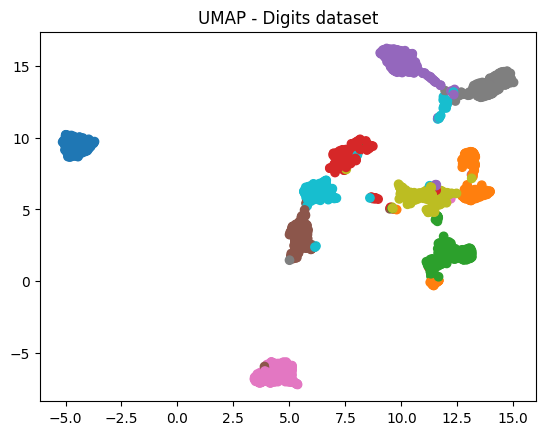

In [13]:
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
import umap
import matplotlib.pyplot as plt

digits = load_digits()
X = digits.data
y = digits.target

X_scaled = StandardScaler().fit_transform(X)

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

X_umap = reducer.fit_transform(X_scaled)

plt.scatter(X_umap[:,0], X_umap[:,1], c=y, cmap="tab10")
plt.title("UMAP - Digits dataset")
plt.show()

UMAP toma las 64 variables originales del dataset y las proyecta a 2 dimensiones, tratando de mantener juntas las imágenes que eran parecidas en el espacio original. Por eso aparecen agrupamientos de dígitos similares

**Isomap**

In [6]:
from sklearn.datasets import load_digits
from sklearn.manifold import Isomap
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd

digits = load_digits()

load_digits: Cada observación corresponde a una imagen pequeña de un número escrito a mano. Las imágenes tienen un tamaño de 8×8 píxeles, por lo que cada imagen se convierte en un vector de 64 variables (8×8 = 64). Cada una de estas variables representa la intensidad de un píxel en escala de grises, con valores entre 0 y 16, donde 0 indica un píxel claro y valores más altos indican mayor oscuridad. En total, el dataset contiene 1797 imágenes, lo que significa que la matriz de datos tiene dimensión 1797 × 64.

In [4]:
digits.data.shape

(1797, 64)

In [10]:
df = pd.DataFrame(digits.data)
df.columns = [f"pixel{i}" for i in range(df.shape[1])]
df["target"] = digits.target
df.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel55,pixel56,pixel57,pixel58,pixel59,pixel60,pixel61,pixel62,pixel63,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


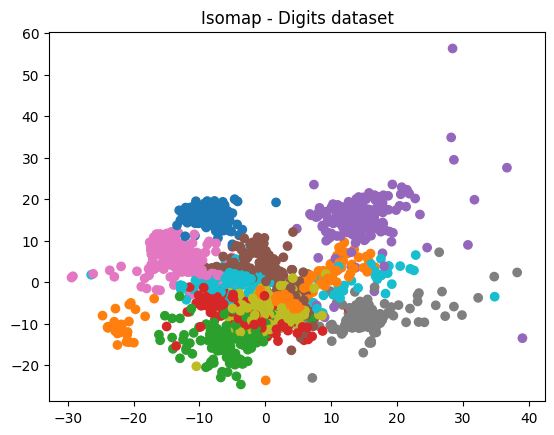

In [1]:
X = digits.data
y = digits.target

X_scaled = StandardScaler().fit_transform(X)

# Hiperparámetros importantes
# n_neighbors: Define cuántos vecinos usar para construir el grafo.
# Valores pequeños:capturan estructura local
# Valores grandes:capturan estructura más global
# n_components: Dimensión final (igual que PCA o t-SNE).
iso = Isomap(n_neighbors=10, n_components=2)

X_iso = iso.fit_transform(X_scaled)

plt.scatter(X_iso[:,0], X_iso[:,1], c=y, cmap="tab10")
plt.title("Isomap - Digits dataset")
plt.show()

**1) Cargar el dataset**

Cada punto en el gráfico es:
* una imagen de un número escrito a mano
* representada originalmente por 64 píxeles
* proyectada a 2 dimensiones usando Isomap

El color representa la clase del número (0–9).

Cada punto representa una imagen de un número escrito a mano. Isomap reduce las 64 dimensiones del espacio de píxeles a dos dimensiones intentando preservar la estructura geométrica del dataset. En el gráfico observamos agrupaciones de números similares, aunque algunos dígitos se superponen debido a su similitud visual.

**Autoencoders**

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.1609 - val_loss: 0.0939
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0838 - val_loss: 0.0758
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0754 - val_loss: 0.0748
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0737 - val_loss: 0.0746
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0737 - val_loss: 0.0740
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0733 - val_loss: 0.0718
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0700 - val_loss: 0.0653
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0653 - val_loss: 0.0625
Epoch 9/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0627 - val_loss: 0.0608
Epoch 10/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0605 - val_loss: 0.0589
Epoch 11/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0591 - val_loss: 0.0574
Epoch 12/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0571 - v

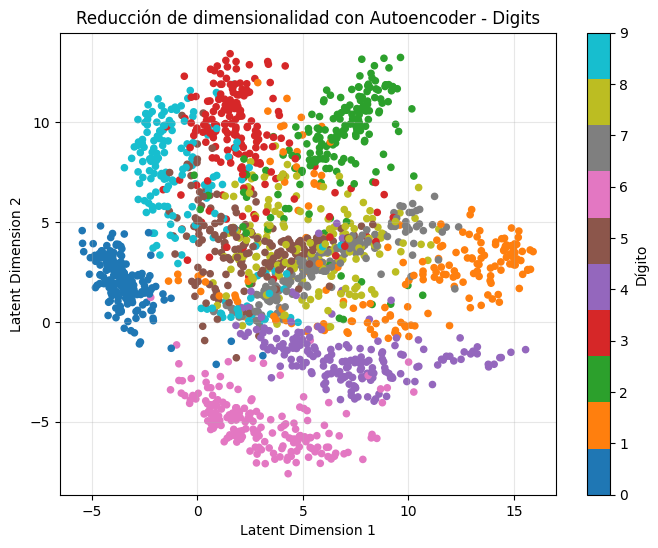

In [14]:
from sklearn.datasets import load_digits
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model

# 1. Cargar dataset
digits = load_digits()
X = digits.data
y = digits.target

# 2. Escalar datos entre 0 y 1
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# 3. Definir dimensiones
input_dim = X_scaled.shape[1]   # 64
encoding_dim = 2                # reducción a 2 dimensiones

# 4. Construir autoencoder
input_layer = layers.Input(shape=(input_dim,))

# Encoder
encoded = layers.Dense(32, activation='relu')(input_layer)
encoded = layers.Dense(16, activation='relu')(encoded)
latent = layers.Dense(encoding_dim, activation='linear', name='latent_space')(encoded)

# Decoder
decoded = layers.Dense(16, activation='relu')(latent)
decoded = layers.Dense(32, activation='relu')(decoded)
output_layer = layers.Dense(input_dim, activation='sigmoid')(decoded)

# Modelo completo
autoencoder = Model(inputs=input_layer, outputs=output_layer)

# Modelo encoder separado
encoder = Model(inputs=input_layer, outputs=latent)

# 5. Compilar
autoencoder.compile(optimizer='adam', loss='mse')

# 6. Entrenar
history = autoencoder.fit(
    X_scaled, X_scaled,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# 7. Obtener representación reducida
X_encoded = encoder.predict(X_scaled)

# 8. Graficar espacio latente
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_encoded[:, 0], X_encoded[:, 1], c=y, cmap='tab10', s=20)
plt.colorbar(scatter, label="Dígito")
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("Reducción de dimensionalidad con Autoencoder - Digits")
plt.grid(True, alpha=0.3)
plt.show()

## LIVE CODING 1

In [ ]:
from sklearn.datasets import load_wine
import pandas as pd

wine = load_wine()
X = wine.data
y = wine.target

df = pd.DataFrame(X, columns=wine.feature_names)
df["target"] = y

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [ ]:
df.shape

(178, 14)

**2) Estandarizar los datos**

Esto es importante, sobre todo para PCA, porque las variables vienen en escalas distintas.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**3) Aplicar PCA**

In [ ]:
from sklearn.decomposition import PCA
import pandas as pd

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["target"] = y

print(df_pca.head())

        PC1       PC2  target
0  3.316751  1.443463       0
1  2.209465 -0.333393       0
2  2.516740  1.031151       0
3  3.757066  2.756372       0
4  1.008908  0.869831       0


In [ ]:
import pandas as pd

componentes = pd.DataFrame(
    pca.components_,
    columns=wine.feature_names,
    index=["PC1", "PC2"]
)

componentes

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
PC1,0.144329,-0.245188,-0.002051,-0.239320,0.141992,0.394661,0.422934,-0.298533,0.313429,-0.088617,0.296715,0.376167,0.286752
PC2,0.483652,0.224931,0.316069,-0.010591,0.299634,0.065040,-0.003360,0.028779,0.039302,0.529996,-0.279235,-0.164496,0.364903


**4) Ver cuánta varianza explican las componentes**

In [ ]:
print("Varianza explicada por cada componente:", pca.explained_variance_ratio_)
print("Varianza explicada acumulada:", pca.explained_variance_ratio_.sum())

Varianza explicada por cada componente: [0.36198848 0.1920749 ]
Varianza explicada acumulada: 0.5540633835693526


**5) Graficar PCA**

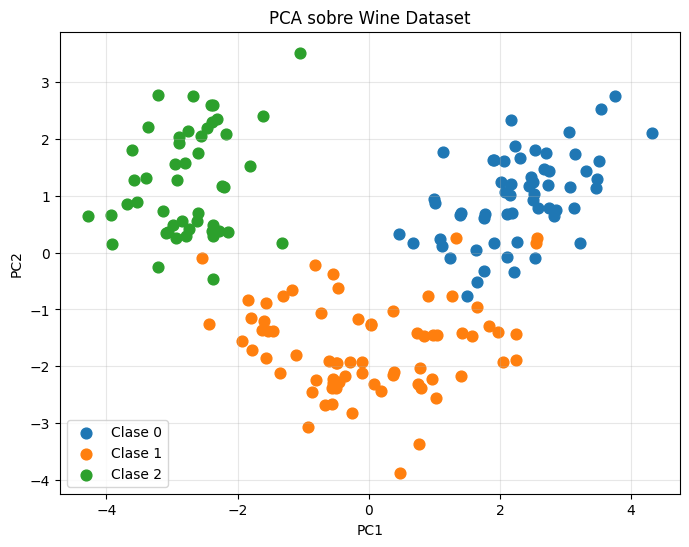

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for clase in sorted(df_pca["target"].unique()):
    subset = df_pca[df_pca["target"] == clase]
    plt.scatter(subset["PC1"], subset["PC2"], label=f"Clase {clase}", s=60)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA sobre Wine Dataset")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**6) Aplicar t-SNE**

También se utilizan los datos escalados.

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

df_tsne = pd.DataFrame(X_tsne, columns=["Dim1", "Dim2"])
df_tsne["target"] = y

print(df_tsne.head())

        Dim1      Dim2  target
0  10.311771 -8.546624       0
1   8.054532 -5.551340       0
2  12.126210 -3.887138       0
3  12.968869 -6.844522       0
4   9.538611 -0.349233       0


**7) Graficar t-SNE**

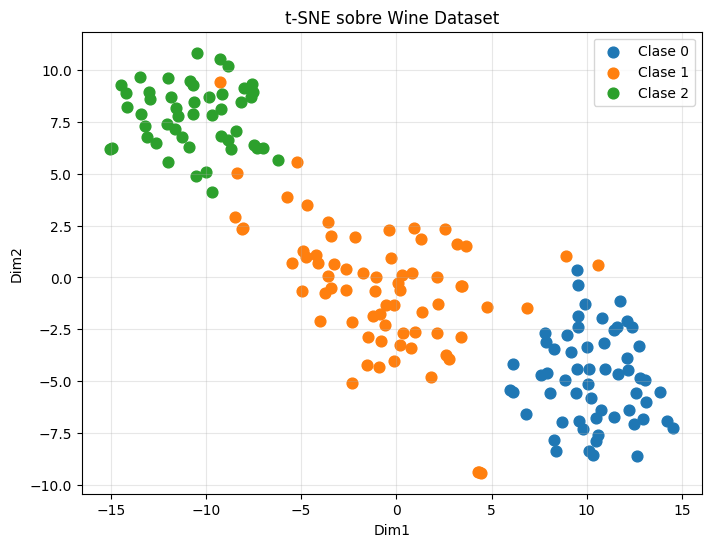

In [ ]:
plt.figure(figsize=(8,6))

for clase in sorted(df_tsne["target"].unique()):
    subset = df_tsne[df_tsne["target"] == clase]
    plt.scatter(subset["Dim1"], subset["Dim2"], label=f"Clase {clase}", s=60)

plt.xlabel("Dim1")
plt.ylabel("Dim2")
plt.title("t-SNE sobre Wine Dataset")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**8) Comparar PCA y t-SNE en una sola figura**

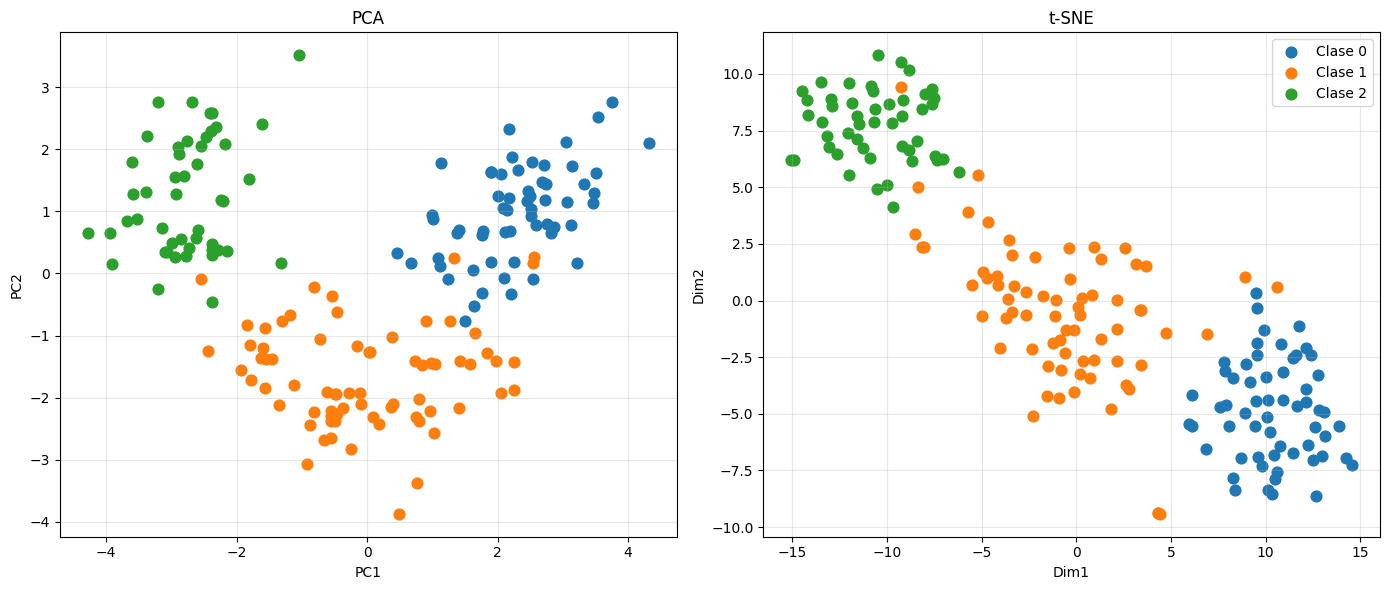

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# PCA
for clase in sorted(df_pca["target"].unique()):
    subset = df_pca[df_pca["target"] == clase]
    axes[0].scatter(subset["PC1"], subset["PC2"], label=f"Clase {clase}", s=60)

axes[0].set_title("PCA")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].grid(True, alpha=0.3)

# t-SNE
for clase in sorted(df_tsne["target"].unique()):
    subset = df_tsne[df_tsne["target"] == clase]
    axes[1].scatter(subset["Dim1"], subset["Dim2"], label=f"Clase {clase}", s=60)

axes[1].set_title("t-SNE")
axes[1].set_xlabel("Dim1")
axes[1].set_ylabel("Dim2")
axes[1].grid(True, alpha=0.3)

axes[1].legend()
plt.tight_layout()
plt.show()

PCA intenta representar los datos lo mejor posible en menos dimensiones.

t-SNE intenta mostrar la estructura de clusters lo más clara posible.

Por eso t-SNE suele verse más bonito, pero PCA es más interpretable.

**PCA + t-SNE + KMeans sobre el dataset Wine**

Silhouette Score de KMeans: 0.285


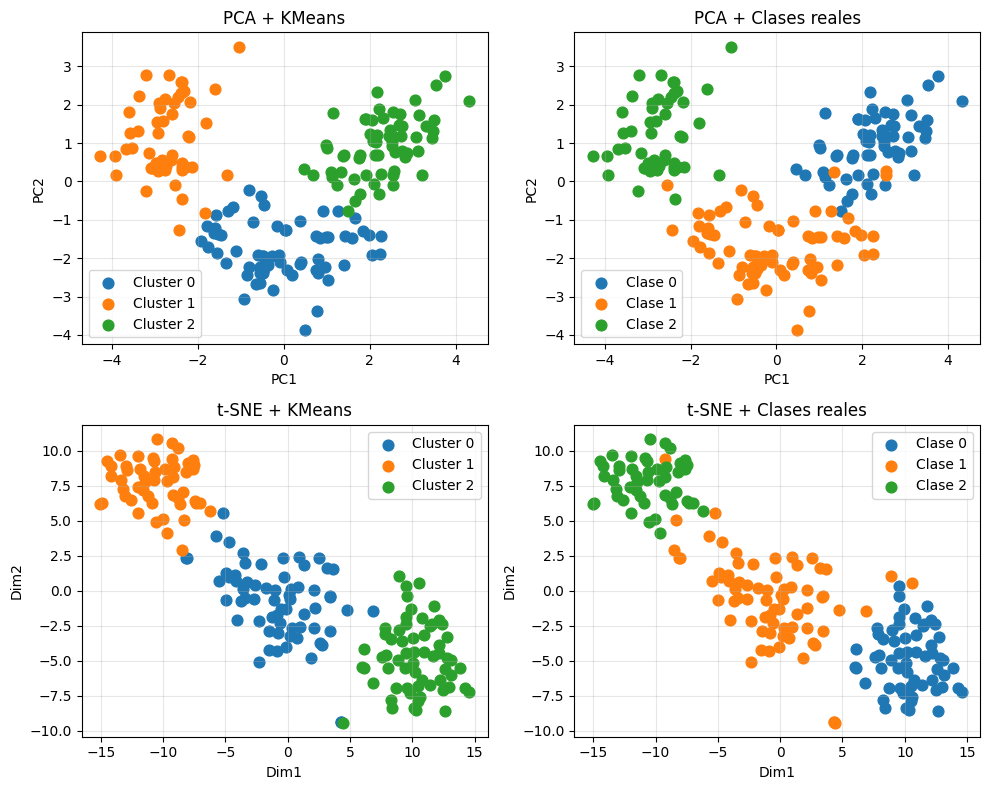

Varianza explicada por PC1 y PC2: [0.36198848 0.1920749 ]
Varianza explicada acumulada: 0.5540633835693526


In [ ]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
import pandas as pd
import matplotlib.pyplot as plt

# 1) Cargar dataset
wine = load_wine()
X = wine.data
y_real = wine.target  # clases reales, solo para comparar visualmente

# 2) Escalar variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3) Aplicar KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# 4) Métrica opcional
sil = silhouette_score(X_scaled, clusters)
print(f"Silhouette Score de KMeans: {sil:.3f}")

# 5) PCA a 2 dimensiones
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["Cluster"] = clusters
df_pca["ClaseReal"] = y_real

# 6) t-SNE a 2 dimensiones
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

df_tsne = pd.DataFrame(X_tsne, columns=["Dim1", "Dim2"])
df_tsne["Cluster"] = clusters
df_tsne["ClaseReal"] = y_real

# 7) Gráficos
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# --- PCA con clusters de KMeans ---
for c in sorted(df_pca["Cluster"].unique()):
    subset = df_pca[df_pca["Cluster"] == c]
    axes[0, 0].scatter(subset["PC1"], subset["PC2"], label=f"Cluster {c}", s=60)

axes[0, 0].set_title("PCA + KMeans")
axes[0, 0].set_xlabel("PC1")
axes[0, 0].set_ylabel("PC2")
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# --- PCA con clases reales ---
for c in sorted(df_pca["ClaseReal"].unique()):
    subset = df_pca[df_pca["ClaseReal"] == c]
    axes[0, 1].scatter(subset["PC1"], subset["PC2"], label=f"Clase {c}", s=60)

axes[0, 1].set_title("PCA + Clases reales")
axes[0, 1].set_xlabel("PC1")
axes[0, 1].set_ylabel("PC2")
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# --- t-SNE con clusters de KMeans ---
for c in sorted(df_tsne["Cluster"].unique()):
    subset = df_tsne[df_tsne["Cluster"] == c]
    axes[1, 0].scatter(subset["Dim1"], subset["Dim2"], label=f"Cluster {c}", s=60)

axes[1, 0].set_title("t-SNE + KMeans")
axes[1, 0].set_xlabel("Dim1")
axes[1, 0].set_ylabel("Dim2")
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# --- t-SNE con clases reales ---
for c in sorted(df_tsne["ClaseReal"].unique()):
    subset = df_tsne[df_tsne["ClaseReal"] == c]
    axes[1, 1].scatter(subset["Dim1"], subset["Dim2"], label=f"Clase {c}", s=60)

axes[1, 1].set_title("t-SNE + Clases reales")
axes[1, 1].set_xlabel("Dim1")
axes[1, 1].set_ylabel("Dim2")
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# 8) Varianza explicada por PCA
print("Varianza explicada por PC1 y PC2:", pca.explained_variance_ratio_)
print("Varianza explicada acumulada:", pca.explained_variance_ratio_.sum())

# **PARTE 2**

**Selección del Número de Componentes**

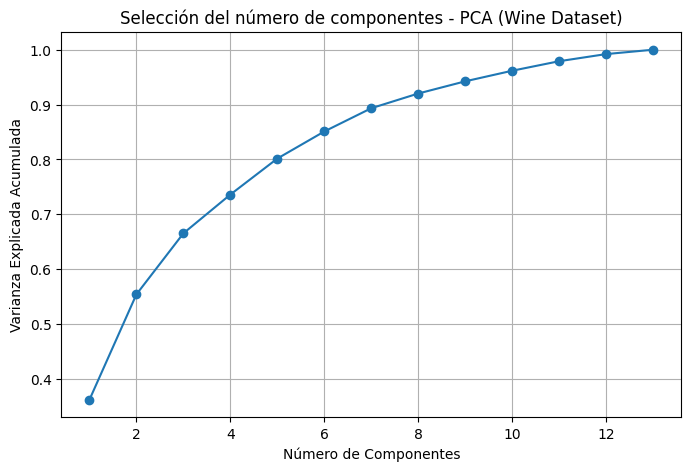

Varianza explicada por componente:
[0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019 0.01736836 0.01298233
 0.00795215]

Varianza acumulada:
[0.36198848 0.55406338 0.66529969 0.73598999 0.80162293 0.85098116
 0.89336795 0.92017544 0.94239698 0.96169717 0.97906553 0.99204785
 1.        ]


In [ ]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# 1) Cargar dataset
wine = load_wine()
X = wine.data

# 2) Escalar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3) PCA sin limitar número de componentes
pca = PCA()
pca.fit(X_scaled)

# 4) Varianza explicada
var_exp = pca.explained_variance_ratio_

# 5) Varianza acumulada
var_acum = np.cumsum(var_exp)

# 6) Graficar
plt.figure(figsize=(8,5))

plt.plot(range(1, len(var_acum)+1), var_acum, marker='o')

plt.xlabel("Número de Componentes")
plt.ylabel("Varianza Explicada Acumulada")
plt.title("Selección del número de componentes - PCA (Wine Dataset)")
plt.grid(True)

plt.show()

# Mostrar valores numéricos
print("Varianza explicada por componente:")
print(var_exp)

print("\nVarianza acumulada:")
print(var_acum)

**3D**

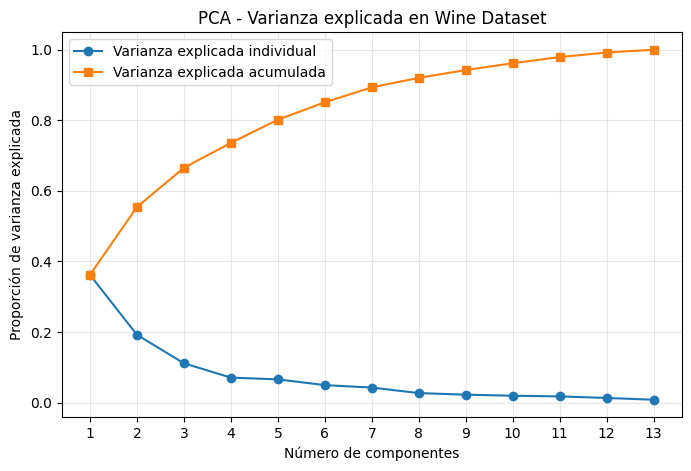

Componente 1: individual=0.3620 | acumulada=0.3620
Componente 2: individual=0.1921 | acumulada=0.5541
Componente 3: individual=0.1112 | acumulada=0.6653
Componente 4: individual=0.0707 | acumulada=0.7360
Componente 5: individual=0.0656 | acumulada=0.8016
Componente 6: individual=0.0494 | acumulada=0.8510
Componente 7: individual=0.0424 | acumulada=0.8934
Componente 8: individual=0.0268 | acumulada=0.9202
Componente 9: individual=0.0222 | acumulada=0.9424
Componente 10: individual=0.0193 | acumulada=0.9617
Componente 11: individual=0.0174 | acumulada=0.9791
Componente 12: individual=0.0130 | acumulada=0.9920
Componente 13: individual=0.0080 | acumulada=1.0000


In [ ]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar dataset
wine = load_wine()
X = wine.data

# 2. Estandarizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Ajustar PCA con todas las componentes
pca = PCA()
pca.fit(X_scaled)

# 4. Obtener varianza explicada
var_exp = pca.explained_variance_ratio_
var_exp_acum = np.cumsum(var_exp)

# 5. Graficar
plt.figure(figsize=(8,5))
plt.plot(range(1, len(var_exp) + 1), var_exp, marker='o', label='Varianza explicada individual')
plt.plot(range(1, len(var_exp_acum) + 1), var_exp_acum, marker='s', label='Varianza explicada acumulada')

plt.xlabel("Número de componentes")
plt.ylabel("Proporción de varianza explicada")
plt.title("PCA - Varianza explicada en Wine Dataset")
plt.xticks(range(1, len(var_exp) + 1))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 6. Mostrar valores
for i, (v, va) in enumerate(zip(var_exp, var_exp_acum), start=1):
    print(f"Componente {i}: individual={v:.4f} | acumulada={va:.4f}")

* La línea de varianza individual te dice cuánto aporta cada componente por separado.
* La línea de varianza acumulada te dice cuánta información llevas acumulada hasta ese punto.

En wine, normalmente pasa algo como esto:
* con 2 componentes conservas una parte importante, pero no toda
* con 3, 4 o 5 ya capturas bastante más información
* entonces 2 componentes suele elegirse para visualizar, no necesariamente porque sea el número “óptimo” para análisis completo

## Métodos para seleccionar componentes

Regla del Codo (Elbow Method)

La idea es:
Mirar el gráfico de varianza explicada por componente y encontrar el punto donde la mejora empieza a ser pequeña.

En el Wine dataset suele verse algo así:

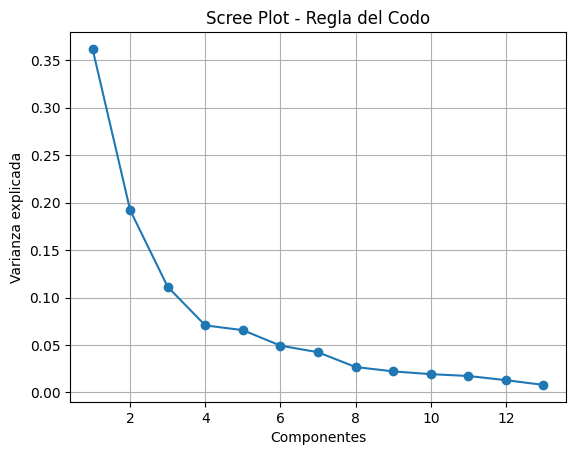

In [ ]:
pca = PCA()
pca.fit(X_scaled)

var_exp = pca.explained_variance_ratio_

plt.plot(range(1, len(var_exp)+1), var_exp, marker='o')
plt.xlabel("Componentes")
plt.ylabel("Varianza explicada")
plt.title("Scree Plot - Regla del Codo")
plt.grid(True)
plt.show()

después de la componente 3 o 4, agregar más componentes aporta poco.

2. Umbral de Varianza

Este método es más directo.

Elegimos el número mínimo de componentes que expliquen cierto porcentaje de varianza.

In [ ]:
pca = PCA(n_components=0.90)
X_pca = pca.fit_transform(X_scaled)

print("Componentes seleccionados:", pca.n_components_)

Componentes seleccionados: 8


3. Validación Cruzada

Este método es más avanzado.

Aquí no miramos solo la varianza, sino cómo afecta el número de componentes al rendimiento de un modelo.

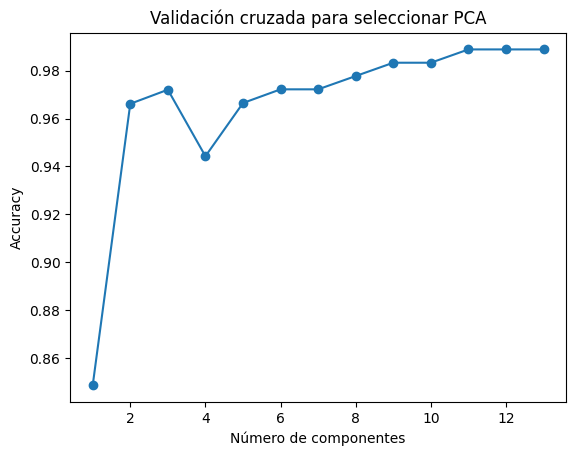

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

scores = []

for k in range(1, 14):

    pipe = Pipeline([
        ("pca", PCA(n_components=k)),
        ("model", LogisticRegression())
    ])

    score = cross_val_score(pipe, X_scaled, y, cv=5).mean()
    scores.append(score)

plt.plot(range(1,14), scores, marker="o")
plt.xlabel("Número de componentes")
plt.ylabel("Accuracy")
plt.title("Validación cruzada para seleccionar PCA")
plt.show()

Aquí el número de componentes se elige donde el modelo tenga mejor rendimiento

**Wine + PCA + 3 métodos**

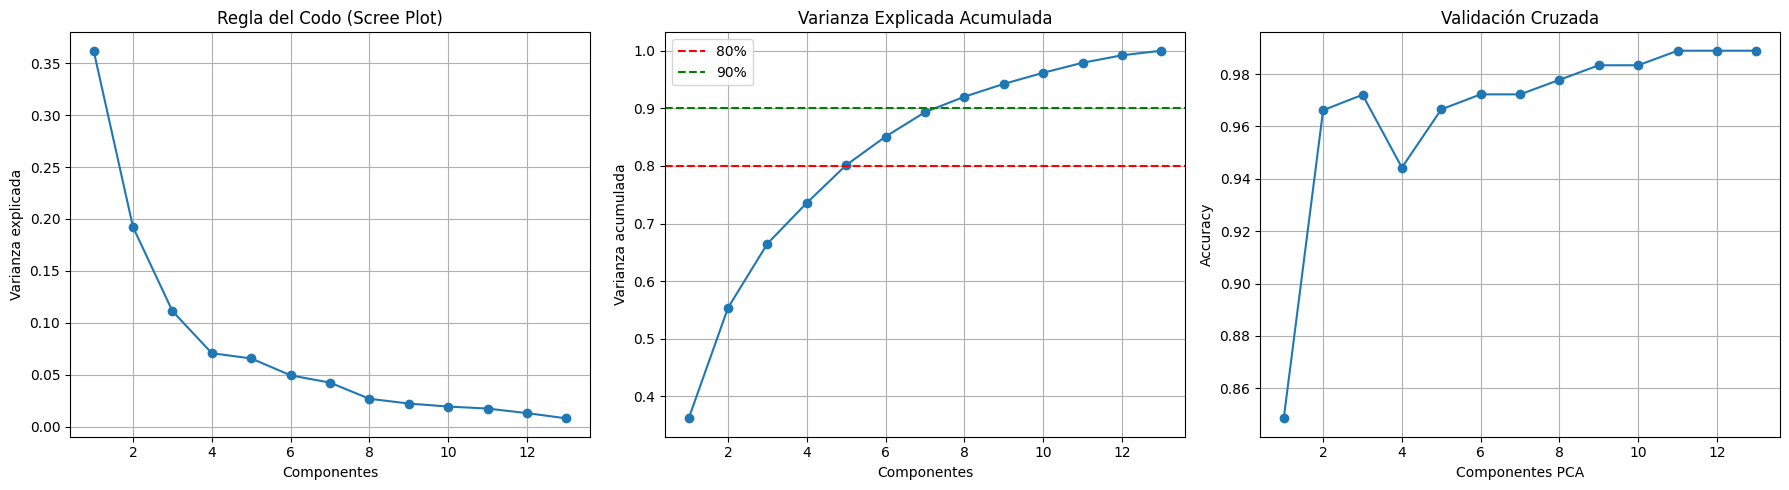

In [ ]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar datos
wine = load_wine()
X = wine.data
y = wine.target

# 2. Escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. PCA completo
pca = PCA()
pca.fit(X_scaled)

var_exp = pca.explained_variance_ratio_
var_acum = np.cumsum(var_exp)

# 4. Validación cruzada
scores = []

for k in range(1, 14):

    pipe = Pipeline([
        ("pca", PCA(n_components=k)),
        ("model", LogisticRegression(max_iter=500))
    ])

    score = cross_val_score(pipe, X_scaled, y, cv=5).mean()
    scores.append(score)

# 5. Gráficos
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# --- Scree plot ---
axes[0].plot(range(1,14), var_exp, marker='o')
axes[0].set_title("Regla del Codo (Scree Plot)")
axes[0].set_xlabel("Componentes")
axes[0].set_ylabel("Varianza explicada")
axes[0].grid(True)

# --- Varianza acumulada ---
axes[1].plot(range(1,14), var_acum, marker='o')
axes[1].axhline(0.8, color='red', linestyle='--', label="80%")
axes[1].axhline(0.9, color='green', linestyle='--', label="90%")

axes[1].set_title("Varianza Explicada Acumulada")
axes[1].set_xlabel("Componentes")
axes[1].set_ylabel("Varianza acumulada")
axes[1].legend()
axes[1].grid(True)

# --- Validación cruzada ---
axes[2].plot(range(1,14), scores, marker='o')
axes[2].set_title("Validación Cruzada")
axes[2].set_xlabel("Componentes PCA")
axes[2].set_ylabel("Accuracy")
axes[2].grid(True)

plt.tight_layout()
plt.show()

**Error de Reconstrucción (principalmente PCA)**

Otra forma de evaluar reducción de dimensionalidad es medir qué tan bien podemos reconstruir los datos originales desde el espacio reducido.

En PCA esto se puede hacer porque la transformación es lineal e invertible (aproximadamente).

In [ ]:
from sklearn.metrics import mean_squared_error

pca = PCA(n_components=5)

X_reducido = pca.fit_transform(X_scaled)
X_reconstruido = pca.inverse_transform(X_reducido)

error = mean_squared_error(X_scaled, X_reconstruido)

print("Error de reconstrucción:", error)

Error de reconstrucción: 0.19837707244452127


Interpretación:

error bajo → la reducción conserva mucha información

error alto → estamos perdiendo estructura del dataset

En t-SNE esto no se puede hacer, porque no existe una transformación inversa clara.

**Rendimiento de Modelos**

Aquí la idea es práctica:

ver si reducir dimensiones mejora o empeora un modelo de ML.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ("pca", PCA(n_components=5)),
    ("model", LogisticRegression(max_iter=500))
])

score = cross_val_score(pipe, X_scaled, y, cv=5)

print(score.mean())

0.9665079365079364


Esto responde preguntas como:

¿Reducir dimensiones mejora la generalización?

¿Elimina ruido?

¿reduce overfitting?

**Preservación de Distancias**

Esto se usa más en técnicas como:
* t-SNE
* UMAP
* MDS

La idea es comparar si las distancias entre puntos se mantienen después de reducir dimensiones.

In [ ]:
from sklearn.metrics import mean_squared_error

pca = PCA(n_components=5)

X_reducido = pca.fit_transform(X_scaled)
X_reconstruido = pca.inverse_transform(X_reducido)

error = mean_squared_error(X_scaled, X_reconstruido)

print("Error de reconstrucción:", error)

Error de reconstrucción: 0.19837707244452127


Interpretación:
* cercano a 1 → la estructura geométrica se conserva
* cercano a 0 → se distorsionó mucho

Nota: t-SNE no intenta preservar todas las distancias, sino vecindades locales.

## LIVE CODING 2

El dataset Penguins proviene del proyecto Palmer Station Long Term Ecological Research, cuyo objetivo es estudiar poblaciones de pingüinos en la Antártica. Este conjunto de datos contiene mediciones morfológicas y demográficas de tres especies de pingüinos —Adelie, Chinstrap y Gentoo— recolectadas en distintas islas del archipiélago Palmer. Cada registro representa un pingüino individual e incluye variables como medidas del pico, longitud de las aletas, peso corporal, sexo y ubicación de observación. Debido a que combina variables numéricas y categóricas con diferencias claras entre especies, este dataset se utiliza frecuentemente en análisis exploratorio de datos, visualización y técnicas de reducción de dimensionalidad como PCA o t-SNE.

| Campo                 | Descripción                                                        |
| --------------------- | ------------------------------------------------------------------ |
| **species**           | Especie del pingüino observado (Adelie, Chinstrap o Gentoo).       |
| **island**            | Isla donde fue registrado el pingüino (Biscoe, Dream o Torgersen). |
| **bill_length_mm**    | Longitud del pico del pingüino medida en milímetros.               |
| **bill_depth_mm**     | Profundidad del pico del pingüino medida en milímetros.            |
| **flipper_length_mm** | Longitud de la aleta del pingüino medida en milímetros.            |
| **body_mass_g**       | Masa corporal del pingüino medida en gramos.                       |
| **sex**               | Sexo del pingüino (male o female).                                 |
| **year**              | Año en que se registró la observación del pingüino.                |


**Cargar el dataset**

In [ ]:
import seaborn as sns
import pandas as pd

df = sns.load_dataset("penguins")
df = df.dropna()
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [ ]:
X = df[[
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]]

y = df["species"]

**Escalar datos**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**PCA**

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

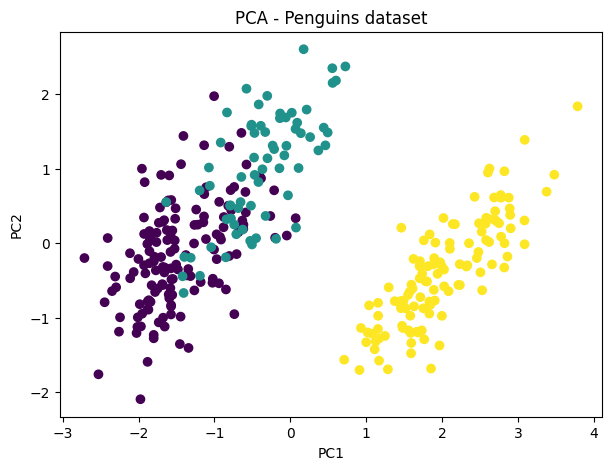

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["species"].astype("category").cat.codes,
    cmap="viridis"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - Penguins dataset")

plt.show()

**Varianza explicada**

In [ ]:
import numpy as np

pca_full = PCA()

pca_full.fit(X_scaled)

var_acum = np.cumsum(pca_full.explained_variance_ratio_)

print(var_acum)

[0.68633893 0.88086822 0.97302885 1.        ]


**t-SNE**

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

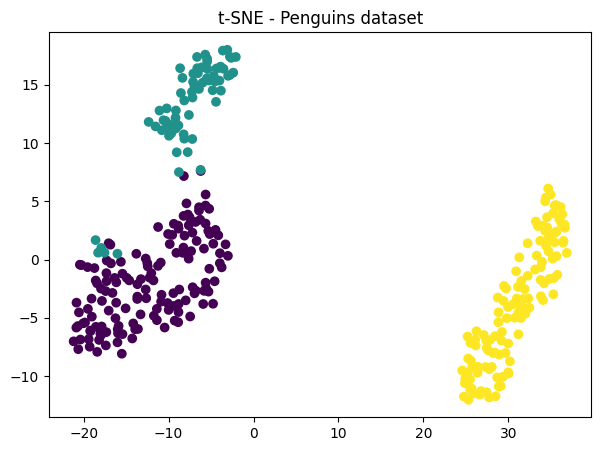

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=df["species"].astype("category").cat.codes,
    cmap="viridis"
)

plt.title("t-SNE - Penguins dataset")

plt.show()

**Comparación PCA vs t-SNE**

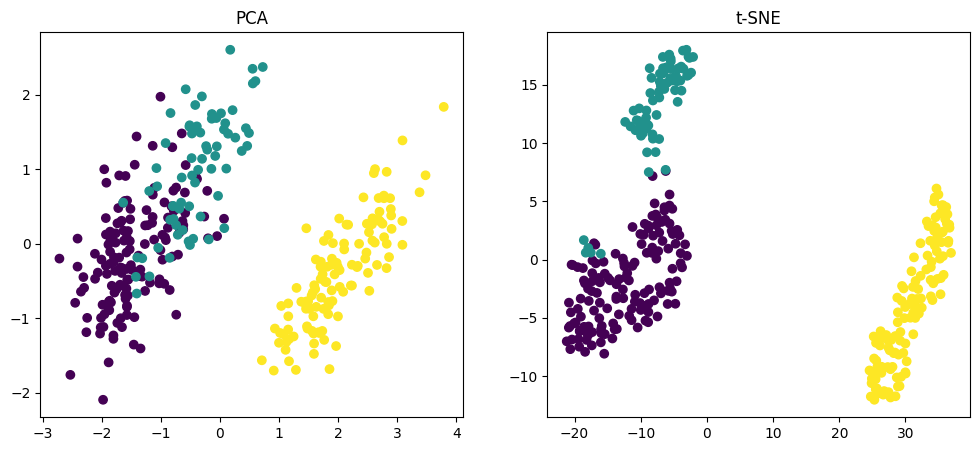

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

axes[0].scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["species"].astype("category").cat.codes,
    cmap="viridis"
)
axes[0].set_title("PCA")

axes[1].scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=df["species"].astype("category").cat.codes,
    cmap="viridis"
)
axes[1].set_title("t-SNE")

plt.show()

Cada punto representa un pingüino.
Las variables describen su tamaño y características físicas.
Usamos PCA para reducir las cuatro variables a dos dimensiones y visualizar cómo se agrupan las especies.

Cuando aplicas PCA al dataset Penguins, lo interesante es que las componentes principales suelen tener una interpretación bastante intuitiva, porque las variables representan características físicas reales de los pingüinos.

En general, las dos primeras componentes principales concentran la mayor parte de la variabilidad del dataset y pueden interpretarse aproximadamente así:

PC1 (Primera componente principal) suele estar fuertemente influenciada por variables relacionadas con el tamaño corporal del pingüino, especialmente flipper_length_mm (longitud de la aleta) y body_mass_g (peso corporal). Esto significa que esta componente separa principalmente a los pingüinos más grandes de los más pequeños. En muchos análisis, esta dimensión distingue claramente a la especie Gentoo, que tiende a ser más grande y pesada que las otras especies.

PC2 (Segunda componente principal) suele estar más asociada con la forma del pico, especialmente con bill_length_mm (longitud del pico) y bill_depth_mm (profundidad del pico). Esta componente ayuda a diferenciar especies que tienen picos de distinta forma, lo que permite separar, por ejemplo, a Adelie y Chinstrap, que pueden tener tamaños similares pero presentan diferencias en las proporciones del pico.

En términos intuitivos, esto significa que el PCA está capturando dos dimensiones biológicas importantes:

tamaño del cuerpo del pingüino, y

morfología del pico.

Cuando se visualizan los datos proyectados en PC1 y PC2, los pingüinos tienden a agruparse en clusters correspondientes a sus especies, lo que hace que este dataset sea especialmente útil para demostrar cómo las técnicas de reducción de dimensionalidad pueden revelar patrones naturales presentes en los datos.